# Notebook 05.2 — Robustez dasimétrica da demanda (teste de sensibilidade)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs
**Apêndice:** I · **Última atualização:** 2026-06-23

---

## Objetivo

Testar a **robustez** do índice de acessibilidade AE2SFCA à hipótese de distribuição uniforme da população dentro do setor censitário. O método de Michels (areal), adotado como principal no NB 05.1, reparte a demanda de cada setor proporcionalmente à **área** da interseção com as isócronas, o que assume população homogênea no polígono. Aqui essa demanda é redistribuída de forma **dasimétrica**, concentrando a população nas **pegadas de construção** (Overture), filtradas pela quantidade de domicílios do setor (Censo 2022), e o índice resultante é comparado ao areal.

Este é um **teste de sensibilidade**, não o método principal. Responde diretamente à crítica do Problema da Unidade de Área Modificável (MAUP) e do viés ecológico: se as conclusões (gradiente centro-periferia, desertos, H1) se mantêm sob um modelo de demanda mais fino, a apropriação areal de Michels está validada.

## Entrada

- `dados/intermediarios/01_malha/teresina_setoresCensitarios_DadosCompletos.parquet` (NB 01.1)
- `dados/externos/overture/zonaUrbana_building_utm.geojson` (NB 01.2, camada COMPLETA)
- `dados/intermediarios/05_isocronas/zonaUrbana_5km_isocronas_carro.parquet` (NB 04.1)
- `dados/externos/cnes/BASE_DE_DADOS_CNES_202604.ZIP` (oferta de equipes de APS)
- IBGE, tabela de domicílios por setor (V00001), baixada automaticamente.

## Saída

- `outputs/tabelas/nb052/nb052_robustez_dasimetrica_comparacao.csv`
- `outputs/figuras/nb052/nb052_robustez_dasi_dispersao.png`
- `outputs/figuras/nb052/nb052_robustez_dasi_reclassificados.png`

## Pré-requisitos

- NB 01.1, 01.2, 04.1 e 05.1 executados.

---

## 1. Configuração e importações

Bibliotecas (incl. `requests`/`zipfile` para os domicílios do IBGE), *helpers* do projeto e criação das subpastas de saída (`nb052`).

In [1]:
# -- 1. IMPORTACOES E CONFIGURACAO -------------------------------------------
import warnings, zipfile, io, requests
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr

from mapeprof.config import (EXT_IBGE, EXT_CNES,
                     EXT_OVERTURE, INT_ISOCRONAS, INT_MALHA,
                     INT_UBS, PROCESSADOS, FIGURAS, TABELAS,
                     CRS_METRICO, criar_diretorios)
from mapeprof.viz import (aplicar_estilo, barra_escala,
                     seta_norte, moldura_mapa,
                     formatar_eixos_mapa, ajustar_zoom_camada)

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb052"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb052"; TABELAS_NB.mkdir(parents=True, exist_ok=True)

FONTE_PADRAO = "CNES/DataSUS; IBGE (2022); Overture Maps Foundation (2026). Elaboração própria."

PESOS = {10: 1.00, 20: 0.68, 30: 0.22}   # pesos gaussianos E2SFCA (10/20/30 min)
print("Pronto.")

Pronto.


## 2. Carga dos setores, domicílios e edificações

Carregamos a população por setor (com a guarda contra os falsos zeros do sigilo), a quantidade de domicílios (V00001, baixada do IBGE e cacheada) e as pegadas de construção.

**Atenção a uma armadilha de dados:** a camada correta de edificações é o GeoJSON completo (`zonaUrbana_building_utm.geojson`, cerca de 419 mil edifícios). Existe na pasta um shapefile homônimo que está **truncado no norte** (cobre só 40% da população) e não deve ser usado. Para acelerar as reexecuções, convertemos o GeoJSON para um parquet de centroides uma única vez.

In [2]:
# -- 2. SETORES: populacao (com guarda 'X'->0) -------------------------------
setores = gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet").to_crs(CRS_METRICO)
setores["populacao"] = pd.to_numeric(setores["populacao"], errors="coerce")
setores.loc[setores["populacao"].fillna(0) <= 0, "populacao"] = np.nan   # sigilo -> ausente
setores["setor_area"] = setores.geometry.area

# -- DOMICILIOS por setor (V00001 = Domicílios Particulares Permanentes Ocupados ), baixado do IBGE e cacheado ---------------
cache_dom = INT_MALHA / "teresina_domicilios_setor.parquet"
if cache_dom.exists():
    dom = pd.read_parquet(cache_dom)
else:
    url = ("https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios/"
           "Agregados_por_Setor_csv/Agregados_por_setores_caracteristicas_domicilio1_BR.zip")
    with zipfile.ZipFile(io.BytesIO(requests.get(url, timeout=180).content)) as z:
        nome = next(n for n in z.namelist() if n.endswith(".csv"))
        with z.open(nome) as f:
            real = {c.upper(): c for c in pd.read_csv(f, sep=";", nrows=0).columns}
            f.seek(0)
            dom = pd.read_csv(f, sep=";", usecols=[real["CD_SETOR"], real["V00001"]], dtype=str)
    dom = dom.rename(columns={real["CD_SETOR"]: "CD_SETOR", real["V00001"]: "domicilios"})
    dom["domicilios"] = pd.to_numeric(dom["domicilios"].replace({"-": 0, "X": np.nan}), errors="coerce")
    dom.to_parquet(cache_dom)
setores = setores.merge(dom, on="CD_SETOR", how="left")
print(f"setores: {len(setores)} | com populacao: {setores['populacao'].notna().sum()} | com domicilios: {setores['domicilios'].notna().sum()}")

setores: 1375 | com populacao: 1340 | com domicilios: 1340


In [3]:
# -- 3. EDIFICACOES: GeoJSON completo -> centroide + area (cacheado) ----------
cache_b = PROCESSADOS / "teresina_edificacoes_centroides.parquet"
if cache_b.exists():
    edif = gpd.read_parquet(cache_b)
else:
    edif = gpd.read_file(EXT_OVERTURE / "zonaUrbana_building_utm.geojson", engine="pyogrio")
    edif = edif.set_crs(CRS_METRICO) if edif.crs is None else edif.to_crs(CRS_METRICO)
    edif["area_build"] = edif.geometry.area      # area da pegada (m2)
    edif["geometry"] = edif.geometry.centroid     # representa a edificacao pelo centroide
    edif = edif[["area_build", "geometry"]].reset_index(drop=True)
    edif.to_parquet(cache_b)
print(f"edificacoes: {len(edif):,}")

edificacoes: 419,573


## 3. Atribuição ao setor e filtro por domicílios

Cada edificação é atribuída ao setor que contém seu centroide. Em seguida aplica-se o **filtro por domicílios**: dentro de cada setor, mantemos as `K` pegadas de maior área, em que `K` é a quantidade de domicílios particulares permanentes ocupados (V00001). A ideia é descartar as menores estruturas (galpões, anexos, puxadinhos) e reter um número de edificações compatível com o de domicílios, aproximando o conjunto residencial.

A população do setor é então redistribuída entre as pegadas mantidas, proporcionalmente à **área de pegada**. Como o total por setor é preservado (ancorado no censo), o método não estima população a partir das construções; ele apenas decide **onde, dentro do setor**, a população (já conhecida) se concentra.

In [4]:
# -- 4. ATRIBUICAO + FILTRO + REDISTRIBUICAO ---------------------------------
edif = gpd.sjoin(edif, setores[["CD_SETOR", "populacao", "domicilios", "geometry"]],
                 how="inner", predicate="within").drop(columns="index_right")

# filtro: mantem as K maiores pegadas por setor (K = domicilios)
edif = edif.sort_values("area_build", ascending=False)
edif["rank"] = edif.groupby("CD_SETOR").cumcount() + 1
edif["K"] = edif["CD_SETOR"].map(setores.set_index("CD_SETOR")["domicilios"].fillna(0).round().astype(int))
res = edif[edif["rank"] <= edif["K"]].copy()

# redistribui a populacao do setor proporcionalmente a area de pegada
res["pop_build"] = res["populacao"] * res["area_build"] / res.groupby("CD_SETOR")["area_build"].transform("sum")
res.to_parquet(PROCESSADOS / "building.parquet", index=False)

pop_total = setores["populacao"].sum()
pop_cob = res["pop_build"].sum()
print(f"pegadas retidas: {len(res):,} | populacao redistribuida: {pop_cob:,.0f} de {pop_total:,.0f} ({pop_cob/pop_total*100:.1f}%)")
print(f"setores com edificacao: {res['CD_SETOR'].nunique()} / {len(setores)}")

pegadas retidas: 235,901 | populacao redistribuida: 804,060 de 807,660 (99.6%)
setores com edificacao: 1333 / 1375


## 4. Cálculo do AE2SFCA: areal (Michels) versus dasimétrico

A oferta ($S_j$, equipes de APS) e as isócronas são as mesmas das duas versões, de modo que a **única diferença é a ponderação da demanda**: por área (Michels) ou por pegada de construção (dasimétrico). No dasimétrico, cada edificação carrega sua parcela de população; a demanda de uma UBS soma as edificações dentro de cada anel, e a acessibilidade de cada edificação é agregada ao setor pela média ponderada pela população.

In [5]:
# -- 5. OFERTA (equipes APS) e ISOCRONAS -------------------------------------
with zipfile.ZipFile(EXT_CNES / "BASE_DE_DADOS_CNES_202604.ZIP") as z:
    eq = pd.read_csv(z.open("tbEquipe202604.csv"), sep=";", encoding="latin-1", dtype=str)
a = eq[(eq["CO_MUNICIPIO"] == "221100") & (eq["DT_DESATIVACAO"].isna())
       & (eq["TP_EQUIPE"].isin({"70", "71"}))].copy()
a["cnes"] = a["CO_UNIDADE"].str[-7:]
oferta = a.groupby("cnes").size().astype(float)        # nº de equipes por UBS (S_j)

iso = gpd.read_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_carro.parquet").to_crs(CRS_METRICO)
iso["w"] = iso["threshold_nominal"].map(PESOS)
iso = iso[iso["ubs_id"].isin(oferta[oferta > 0].index)]  # Michels descarta oferta <= 0


def ae2sfca_areal(iso, setores, oferta):
    # apropriacao por AREA da intersecao isocrona x setor (metodo de Michels)
    ped = gpd.overlay(iso[["ubs_id", "w", "geometry"]],
                      setores[["CD_SETOR", "populacao", "setor_area", "geometry"]],
                      how="intersection", keep_geom_type=True)
    ped["frac"] = (ped.geometry.area / ped["setor_area"]).clip(upper=1.0)
    ped["pp"] = ped["populacao"].fillna(0) * ped["frac"] * ped["w"]
    dem = ped.groupby("ubs_id")["pp"].sum()
    Rj = (oferta.reindex(dem.index) / dem).replace([np.inf, -np.inf], np.nan)
    ped["contrib"] = ped["ubs_id"].map(Rj) * ped["w"] * ped["frac"]
    return ped.groupby("CD_SETOR")["contrib"].sum()


def ae2sfca_dasi(iso, edif, oferta):
    # apropriacao por PEGADA: cada edificacao carrega sua parcela de populacao
    j = gpd.sjoin(edif[["pop_build", "CD_SETOR", "geometry"]],
                  iso[["ubs_id", "w", "geometry"]], how="inner", predicate="within")
    j["pw"] = j["pop_build"] * j["w"]
    dem = j.groupby("ubs_id")["pw"].sum()
    Rj = (oferta.reindex(dem.index) / dem).replace([np.inf, -np.inf], np.nan)
    j["contrib"] = j["ubs_id"].map(Rj) * j["w"]
    acesso_edif = j.groupby(j.index)["contrib"].sum()          # acesso por edificacao
    e = edif.copy(); e["acesso"] = acesso_edif
    e = e.dropna(subset=["acesso"])
    # agrega ao setor: media ponderada pela populacao da edificacao
    return (e["acesso"] * e["pop_build"]).groupby(e["CD_SETOR"]).sum() / e["pop_build"].groupby(e["CD_SETOR"]).sum()


setores["acess_areal"] = setores["CD_SETOR"].map(ae2sfca_areal(iso, setores, oferta)).fillna(0)
setores["acess_dasi"]  = setores["CD_SETOR"].map(ae2sfca_dasi(iso, res, oferta)).fillna(0)
print(f"acesso>0: areal={int((setores['acess_areal']>0).sum())} | dasimetrico={int((setores['acess_dasi']>0).sum())}")

acesso>0: areal=1375 | dasimetrico=1333


## 5. Comparação entre os índices

Comparamos as duas versões por (a) correlação de postos de Spearman entre os índices e (b) reclassificação dos desertos de saúde, definidos como o quartil inferior de cada índice.

In [6]:
# -- 6. COMPARACAO -----------------------------------------------------------
m = setores[(setores["acess_areal"] > 0) & (setores["acess_dasi"] > 0)]
rho, p = spearmanr(m["acess_areal"], m["acess_dasi"])

LIMIAR_QUANTIL = 0.25
for nome, col in [("areal", "acess_areal"), ("dasi", "acess_dasi")]:
    limiar = setores.loc[setores[col] > 0, col].quantile(LIMIAR_QUANTIL)
    setores[f"deserto_{nome}_abs"] = setores[col] == 0
    setores[f"deserto_{nome}_rel"] = (setores[col] > 0) & (setores[col] <= limiar)
    setores[f"deserto_{nome}"]     = setores[f"deserto_{nome}_abs"] | setores[f"deserto_{nome}_rel"]
reclass = int((setores["deserto_areal"] != setores["deserto_dasi"]).sum())

resumo = pd.Series({
    "setores comparados (acesso>0 nos dois)": len(m),
    "Spearman areal x dasimetrico":           round(rho, 3),
    "p-valor":                                f"{p:.1e}",
    "populacao coberta (%)":                  round(pop_cob / pop_total * 100, 1),
    "desertos areal (abs+rel)":               int(setores["deserto_areal"].sum()),
    "desertos dasimetrico (abs+rel)":         int(setores["deserto_dasi"].sum()),
    "setores reclassificados":                reclass,
})
resumo.to_csv(TABELAS_NB / "nb052_robustez_dasimetrica_comparacao.csv", sep=";", encoding="utf-8-sig")
print(resumo.to_string())

setores comparados (acesso>0 nos dois)       1333
Spearman areal x dasimetrico                0.991
p-valor                                   0.0e+00
populacao coberta (%)                        99.6
desertos areal (abs+rel)                      344
desertos dasimetrico (abs+rel)                376
setores reclassificados                        66


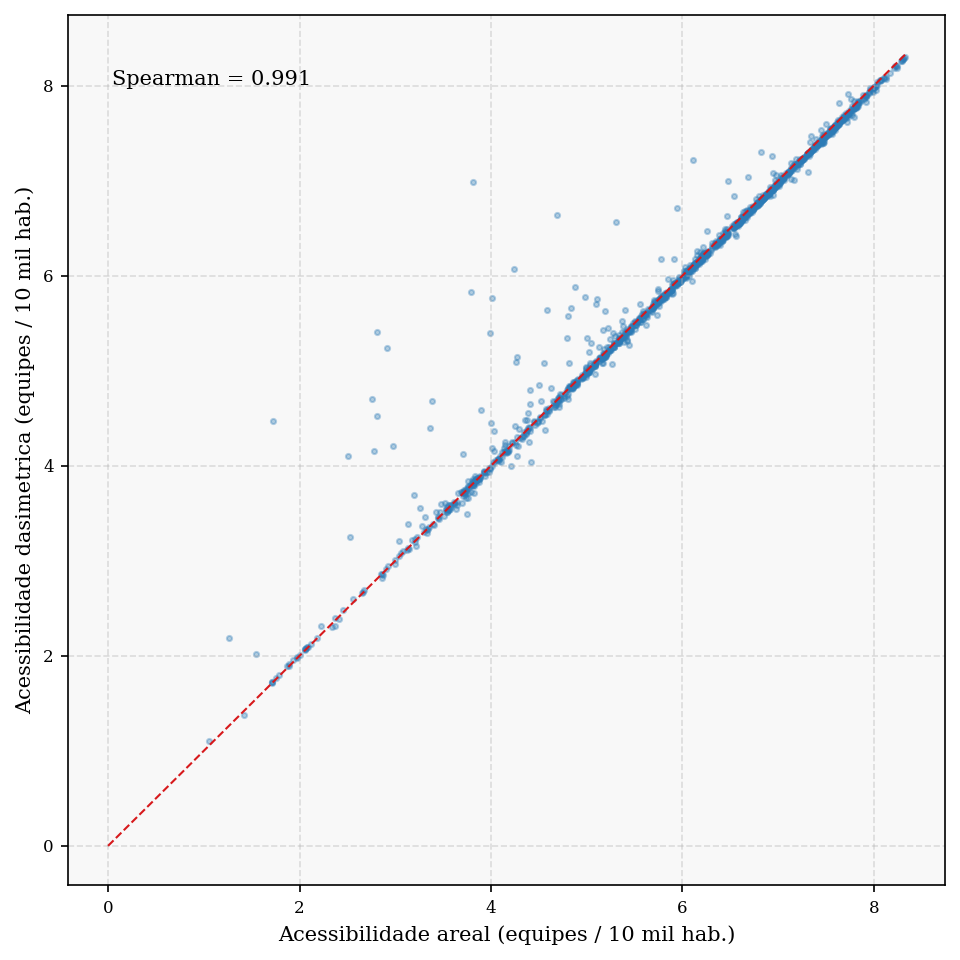

In [7]:
# -- 7. FIGURA: dispersao areal x dasimetrico (x10 mil hab) -------------------
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(m["acess_areal"] * 1e4, m["acess_dasi"] * 1e4, s=6, alpha=0.35, color="#2C7BB6")
lim = max((m["acess_areal"] * 1e4).max(), (m["acess_dasi"] * 1e4).max())
ax.plot([0, lim], [0, lim], color="#D7191C", ls="--", lw=1)   # linha de identidade
ax.set_xlabel("Acessibilidade areal (equipes / 10 mil hab.)")
ax.set_ylabel("Acessibilidade dasimetrica (equipes / 10 mil hab.)")
ax.text(0.05, 0.92, f"Spearman = {rho:.3f}", transform=ax.transAxes, fontsize=10)
fig.tight_layout()
fig.savefig(FIGURAS_NB / "nb052_robustez_dasi_dispersao.png", dpi=300, bbox_inches="tight")
plt.show()

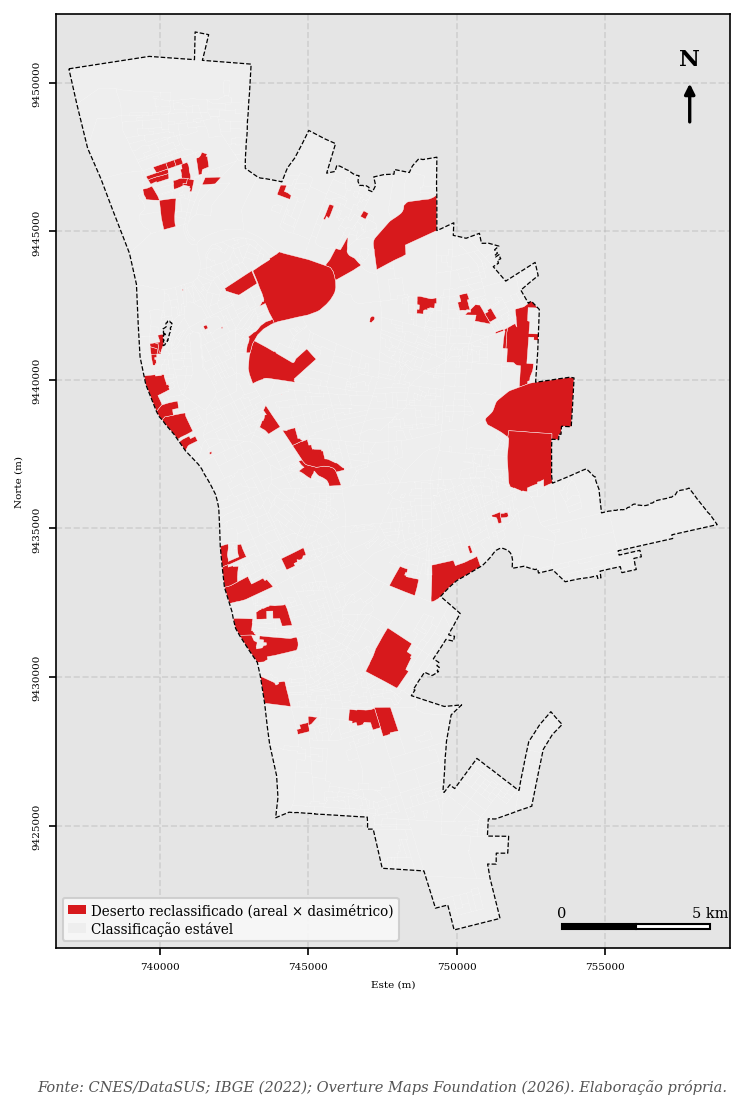

In [8]:
# -- 8. FIGURA: setores que mudam de classificação de deserto ----------------
setores["mudou"] = setores["deserto_areal"] != setores["deserto_dasi"]
gdf_zu = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)

fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1, zorder=2)
setores[setores["mudou"]].plot(ax=ax, color="#D7191C", edgecolor="white", linewidth=0.2, zorder=3)
gdf_zu.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=4)
ax.legend(handles=[Patch(facecolor="#D7191C", label="Deserto reclassificado (areal × dasimétrico)"),
                   Patch(facecolor="#EEEEEE", label="Classificação estável")],
          loc="lower left", fontsize=6.5, framealpha=0.9)
ajustar_zoom_camada(ax, setores, margem=0.02)
moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax, frac_x=0.75, frac_y=0.02); seta_norte(ax)
fig.savefig(FIGURAS_NB / "nb052_robustez_dasi_reclassificados.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Robustez no modo pedestre

Repete-se o teste de sensibilidade para o **modo pedestre**: comparam-se os índices
AE2SFCA **areal** (Michels) e **dasimétrico** calculados sobre as **isócronas a pé**,
mantendo a mesma oferta e a mesma redistribuição da demanda nas pegadas de construção.
Isola-se, assim, o efeito da ponderação da demanda também no deslocamento ativo.

In [9]:
# -- 9. ÍNDICES AREAL × DASIMÉTRICO NO MODO PEDESTRE --------------------------
# Carrega as isócronas a pé (NB 04.1) e mapeia os pesos de decaimento (mesma lógica do carro).
iso_pe = gpd.read_parquet(INT_ISOCRONAS / "zonaUrbana_5km_isocronas_pedestre.parquet").to_crs(CRS_METRICO)
iso_pe["w"] = iso_pe["threshold_nominal"].map(PESOS)
iso_pe = iso_pe[iso_pe["ubs_id"].isin(oferta[oferta > 0].index)]   # descarta UBS sem equipe

# Reaproveita as MESMAS funções do modo carro — só muda a camada de isócronas.
# 'res' (pegadas com população redistribuída) é independente do modo.
setores["acess_areal_pe"] = setores["CD_SETOR"].map(ae2sfca_areal(iso_pe, setores, oferta)).fillna(0)
setores["acess_dasi_pe"]  = setores["CD_SETOR"].map(ae2sfca_dasi(iso_pe, res, oferta)).fillna(0)

print(f"pé | acesso>0: areal={int((setores['acess_areal_pe']>0).sum())} | "
      f"dasimétrico={int((setores['acess_dasi_pe']>0).sum())}")

pé | acesso>0: areal=1357 | dasimétrico=1323


In [10]:
# -- 10. COMPARAÇÃO AREAL × DASIMÉTRICO (PEDESTRE) ---------------------------
LIMIAR_QUANTIL = 0.25   # já definido no modo carro; repetido aqui p/ a célula ser autossuficiente

# considera só setores com acesso nos dois índices (Spearman precisa de pares válidos)
m_pe = setores[(setores["acess_areal_pe"] > 0) & (setores["acess_dasi_pe"] > 0)]
rho_pe, p_pe = spearmanr(m_pe["acess_areal_pe"], m_pe["acess_dasi_pe"])

# desertos no formato absoluto + relativo, para os dois índices a pé
for nome, col in [("areal_pe", "acess_areal_pe"), ("dasi_pe", "acess_dasi_pe")]:
    limiar = setores.loc[setores[col] > 0, col].quantile(LIMIAR_QUANTIL)
    setores[f"deserto_{nome}_abs"] = setores[col] == 0
    setores[f"deserto_{nome}_rel"] = (setores[col] > 0) & (setores[col] <= limiar)
    setores[f"deserto_{nome}"]     = setores[f"deserto_{nome}_abs"] | setores[f"deserto_{nome}_rel"]
reclass_pe = int((setores["deserto_areal_pe"] != setores["deserto_dasi_pe"]).sum())

resumo_pe = pd.Series({
    "setores comparados (acesso>0 nos dois)": len(m_pe),
    "Spearman areal x dasimetrico (pé)":      round(rho_pe, 3),
    "p-valor":                                f"{p_pe:.1e}",
    "desertos areal pé (abs+rel)":            int(setores["deserto_areal_pe"].sum()),
    "desertos dasimetrico pé (abs+rel)":      int(setores["deserto_dasi_pe"].sum()),
    "setores reclassificados (pé)":           reclass_pe,
})
resumo_pe.to_csv(TABELAS_NB / "nb052_robustez_dasimetrica_comparacao_pe.csv",
                 sep=";", encoding="utf-8-sig")
print(resumo_pe.to_string())

setores comparados (acesso>0 nos dois)       1323
Spearman areal x dasimetrico (pé)           0.976
p-valor                                   0.0e+00
desertos areal pé (abs+rel)                   358
desertos dasimetrico pé (abs+rel)             383
setores reclassificados (pé)                   83


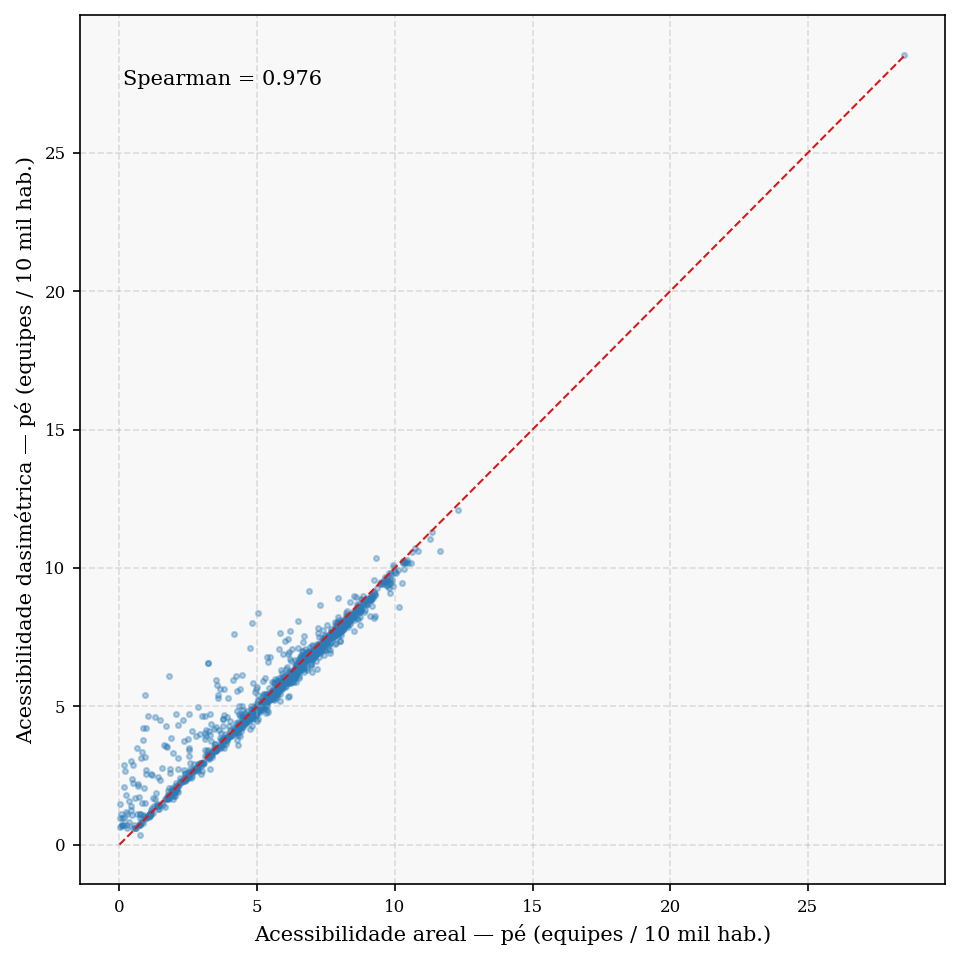

In [11]:
# -- 11. FIGURA: dispersão areal × dasimétrico (pé), por 10 mil hab ----------
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(m_pe["acess_areal_pe"] * 1e4, m_pe["acess_dasi_pe"] * 1e4,
           s=6, alpha=0.35, color="#2C7BB6")
lim = max((m_pe["acess_areal_pe"] * 1e4).max(), (m_pe["acess_dasi_pe"] * 1e4).max())
ax.plot([0, lim], [0, lim], color="#D7191C", ls="--", lw=1)   # linha de identidade
ax.set_xlabel("Acessibilidade areal — pé (equipes / 10 mil hab.)")
ax.set_ylabel("Acessibilidade dasimétrica — pé (equipes / 10 mil hab.)")
ax.text(0.05, 0.92, f"Spearman = {rho_pe:.3f}", transform=ax.transAxes, fontsize=10)
fig.tight_layout()
fig.savefig(FIGURAS_NB / "nb052_robustez_dasi_dispersao_pe.png", dpi=300, bbox_inches="tight")
plt.show()

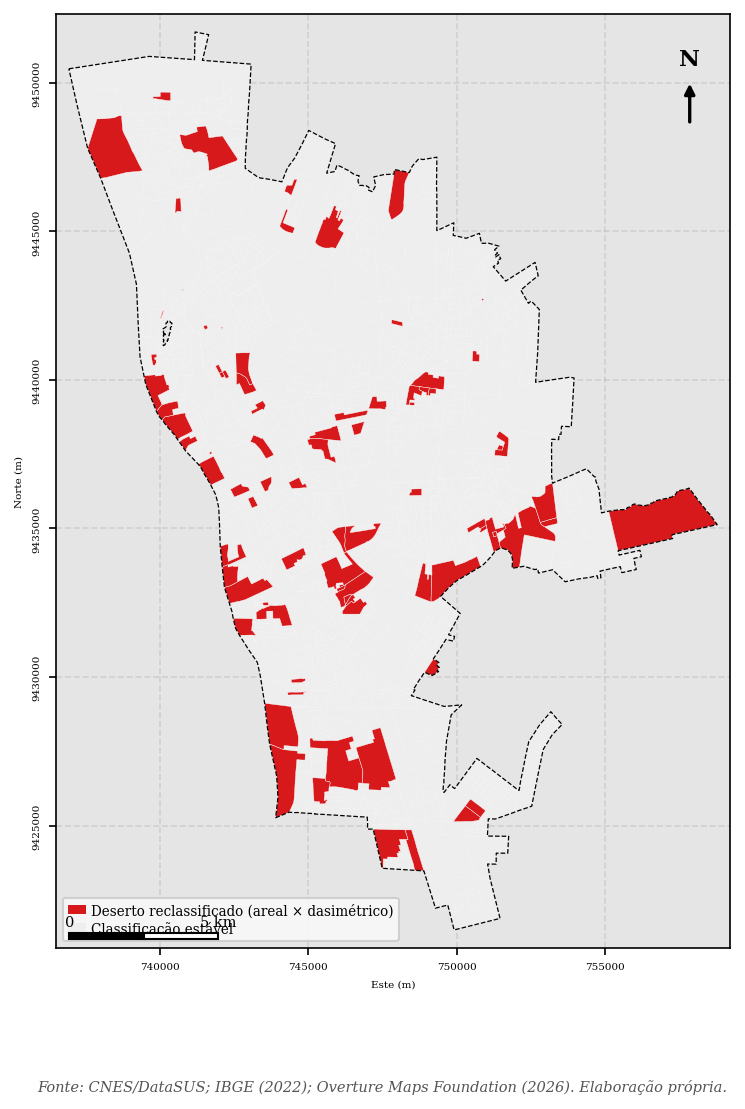

In [12]:
# -- 12. FIGURA: setores que mudam de classificação de deserto (pé) ----------
from matplotlib.patches import Patch
setores["mudou_pe"] = setores["deserto_areal_pe"] != setores["deserto_dasi_pe"]
zona = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)

fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1, zorder=2)
setores[setores["mudou_pe"]].plot(ax=ax, color="#D7191C", edgecolor="white", linewidth=0.2, zorder=3)
zona.boundary.plot(ax=ax, color="black", ls="--", lw=0.6, zorder=4)
ax.legend(handles=[Patch(facecolor="#D7191C", label="Deserto reclassificado (areal × dasimétrico)"),
                   Patch(facecolor="#EEEEEE", label="Classificação estável")],
          loc="lower left", fontsize=6.5, framealpha=0.9)
ajustar_zoom_camada(ax, setores, margem=0.02)
moldura_mapa(ax, "", FONTE_PADRAO)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax); seta_norte(ax)
fig.savefig(FIGURAS_NB / "nb052_robustez_dasi_reclassificados_pe.png", dpi=300, bbox_inches="tight")
plt.show()

### 6.1 Comparação dos índices (pedestre)

Concordância pela correlação de Spearman e pela reclassificação dos desertos
(**absoluto** = sem acesso; **relativo** = quartil inferior dos positivos), na mesma
lógica aplicada ao automóvel.

### 6.2 Síntese visual da robustez (automóvel × pedestre)

Painéis comparativos da robustez dasimétrica nos dois modos: dispersão areal × dasimétrico
e mapas dos setores reclassificados. Quanto mais alinhados à reta de identidade e menos
setores reclassificados, mais robusto é o índice à hipótese de distribuição da demanda.

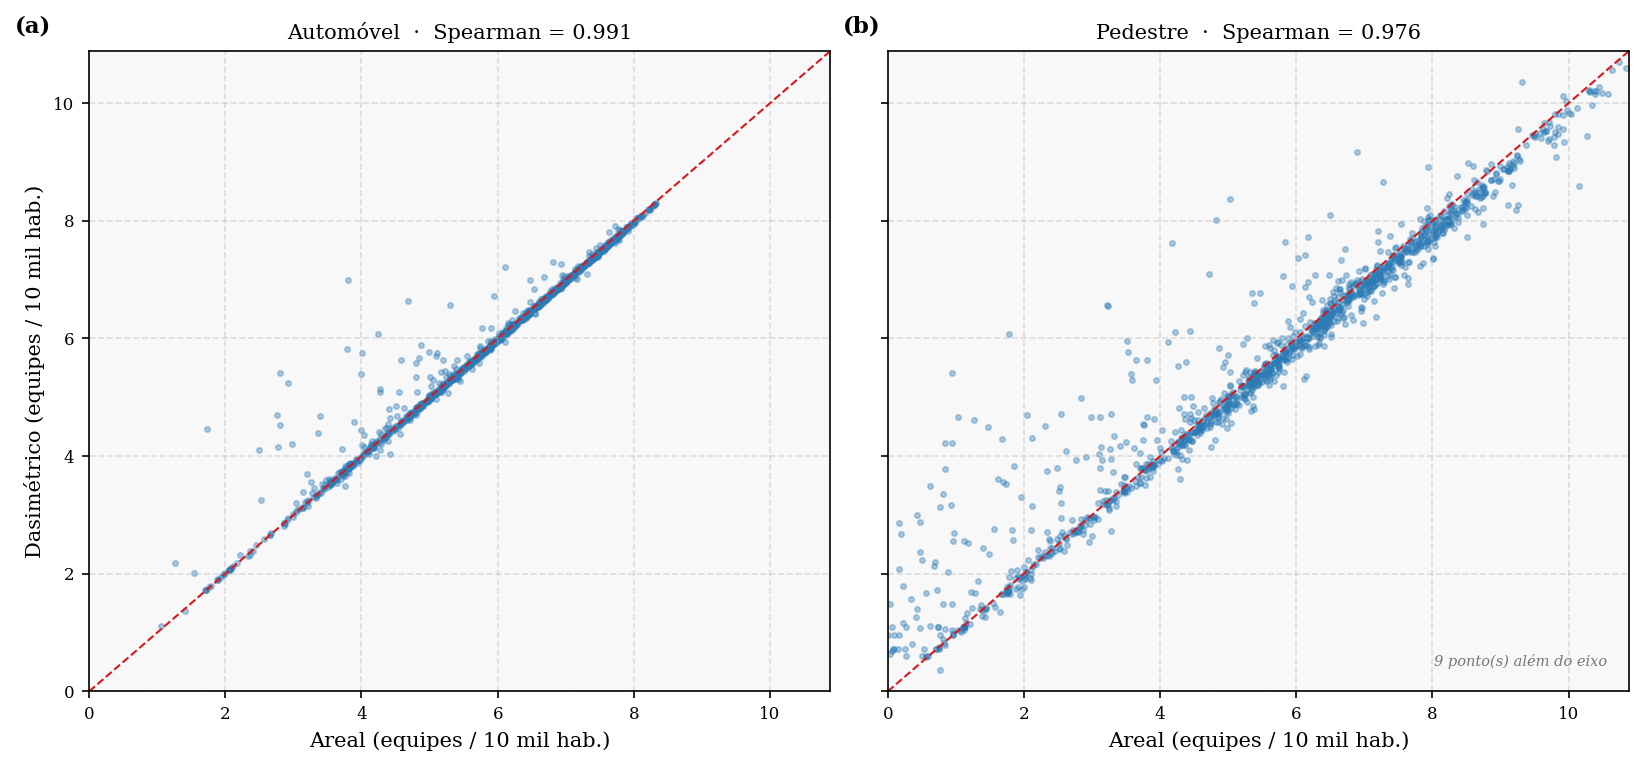

In [13]:
# -- 13. FIGURA: dispersão areal × dasimétrico — painel (a) carro / (b) pé ----
car_a, car_d = m["acess_areal"] * 1e4,    m["acess_dasi"] * 1e4
pe_a,  pe_d  = m_pe["acess_areal_pe"]*1e4, m_pe["acess_dasi_pe"]*1e4

# eixo comum, truncado no p99 do pé p/ neutralizar o outlier (comparabilidade)
L = 1.05 * max(car_a.max(), car_d.max(), np.percentile(pe_a, 99), np.percentile(pe_d, 99))
fora = int((pe_a > L).sum() + (pe_d > L).sum())   # pontos do pé além do eixo

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, (xa, xd, rho_m, nome) in zip(
        (ax1, ax2),
        [(car_a, car_d, rho, "Automóvel"), (pe_a, pe_d, rho_pe, "Pedestre")]):
    ax.scatter(xa, xd, s=6, alpha=0.35, color="#2C7BB6")
    ax.plot([0, L], [0, L], color="#D7191C", ls="--", lw=1)        # reta de identidade
    ax.set_xlim(0, L); ax.set_ylim(0, L)
    ax.set_xlabel("Areal (equipes / 10 mil hab.)")
    ax.set_title(f"{nome}  ·  Spearman = {rho_m:.3f}", fontsize=10)
ax1.set_ylabel("Dasimétrico (equipes / 10 mil hab.)")
ax1.text(-0.10, 1.03, "(a)", transform=ax1.transAxes, fontweight="bold", fontsize=11)
ax2.text(-0.06, 1.03, "(b)", transform=ax2.transAxes, fontweight="bold", fontsize=11)
if fora:
    ax2.text(0.97, 0.04, f"{fora} ponto(s) além do eixo", transform=ax2.transAxes,
             ha="right", fontsize=7, style="italic", color="#777")
fig.tight_layout()
fig.savefig(FIGURAS_NB / "nb052_robustez_dasi_dispersao_painel.png", dpi=300, bbox_inches="tight")
plt.show()

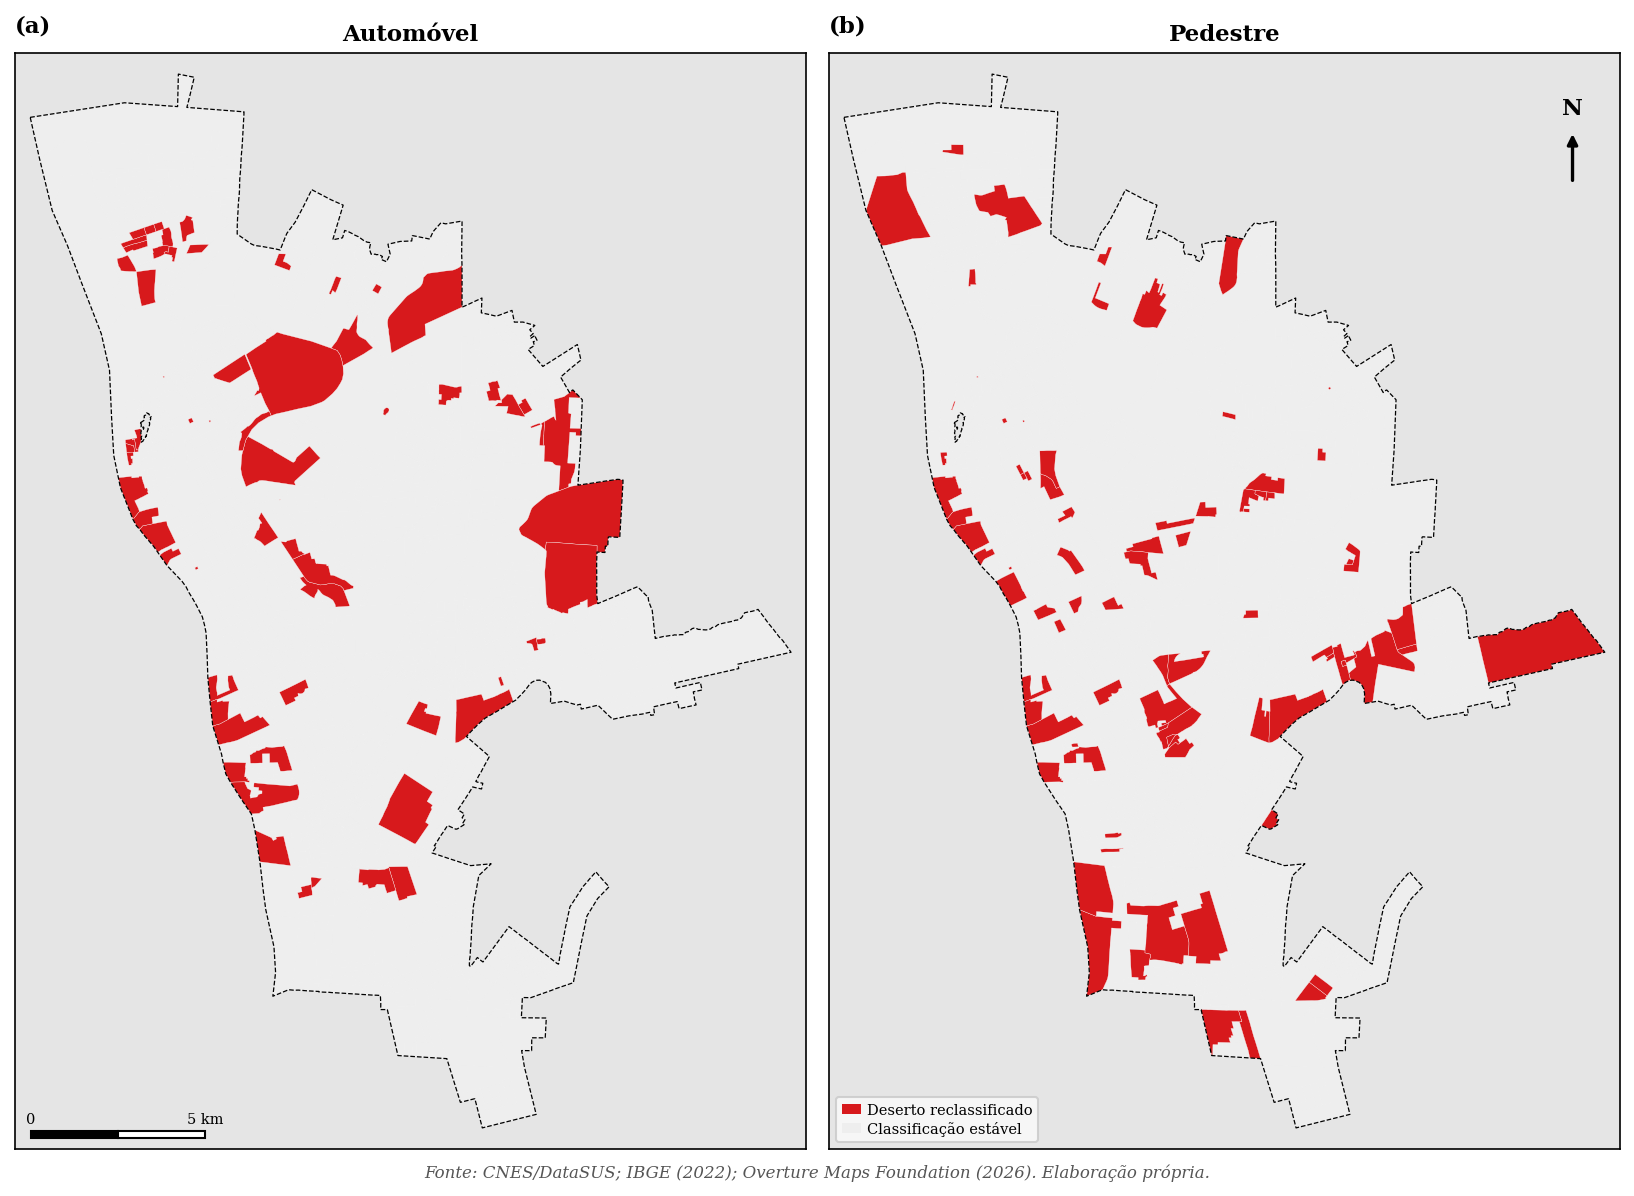

In [14]:
# -- 14. FIGURA: setores reclassificados — painel (a) carro / (b) pé ----------
from matplotlib.patches import Patch
zona = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)

fig, axes = plt.subplots(1, 2, figsize=(11, 8))
for ax, (col, nome) in zip(axes, [("mudou", "Automóvel"), ("mudou_pe", "Pedestre")]):
    ax.set_facecolor("#E5E5E5")
    setores.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.05)
    setores[setores[col]].plot(ax=ax, color="#D7191C", edgecolor="white", linewidth=0.15)
    zona.boundary.plot(ax=ax, color="black", ls="--", lw=0.6)
    ajustar_zoom_camada(ax, setores, margem=0.02)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(nome, fontsize=11, fontweight="bold")
axes[0].text(0.0, 1.02, "(a)", transform=axes[0].transAxes, fontweight="bold", fontsize=11)
axes[1].text(0.0, 1.02, "(b)", transform=axes[1].transAxes, fontweight="bold", fontsize=11)
axes[1].legend(handles=[Patch(facecolor="#D7191C", label="Deserto reclassificado"),
                        Patch(facecolor="#EEEEEE", label="Classificação estável")],
               loc="lower left", fontsize=7, framealpha=0.9)
barra_escala(axes[0]); seta_norte(axes[1])
fig.text(0.5, 0.04, f"Fonte: {FONTE_PADRAO}", ha="center", fontsize=8, style="italic", color="#555")
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIGURAS_NB / "nb052_robustez_dasi_reclassificados_painel.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Conclusão do teste

A alta concordância entre os índices areal e dasimétrico valida a apropriação areal de Michels frente ao MAUP e ao viés ecológico. O resultado fundamenta a **Seção 5.7** do relatório.